In [2]:
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
# STRICT THRESHOLD: Problem is "Solved" only if pass_rate >= 0.95
SUCCESS_THRESHOLD = 0.95 
OUTPUT_FILENAME = 'adaptive_llm_training_data_strict_095.csv'
# ---------------------

# 1. Load the Data
# Ensure these filenames match your directory
df_4b = pd.read_csv('extracted_confidences_qwen4B_it_50problems(Sheet1).csv')
df_32b = pd.read_csv('extracted_confidences_qwen4B_32B_it_50_problems (2)(Sheet1).csv')

# 2. Clean Data
def clean_df(df, model_size):
    cols = ['bottom_window_confidence', 'least_grouped_confidence', 
            'mean_confidence', 'tail_confidence', 'pass_rate']
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['current_model_size'] = model_size
    return df.dropna(subset=cols)

df_4b = clean_df(df_4b, 4)
df_32b = clean_df(df_32b, 32)

# 3. Establish Ground Truth
# We determine if a problem is solvable (>= 0.95) by each model based on specific runs
ground_truth = pd.DataFrame()
all_pids = pd.concat([df_4b['problem_id'], df_32b['problem_id']]).unique()
ground_truth['problem_id'] = all_pids

# Calculate max pass rate achieved by each model per problem
max_pass_4b = df_4b.groupby('problem_id')['pass_rate'].max()
max_pass_32b = df_32b.groupby('problem_id')['pass_rate'].max()

ground_truth = ground_truth.set_index('problem_id')
ground_truth['max_pass_4b'] = max_pass_4b
ground_truth['max_pass_32b'] = max_pass_32b

# Boolean Solvability based on strict threshold
ground_truth['can_4b_solve'] = ground_truth['max_pass_4b'] >= SUCCESS_THRESHOLD
ground_truth['can_32b_solve'] = ground_truth['max_pass_32b'] >= SUCCESS_THRESHOLD
ground_truth.fillna(False, inplace=True)

# 4. Generate Labels (The "Router" Logic)
combined_data = []

def get_target_class(row):
    pid = row['problem_id']
    if pid not in ground_truth.index: return None 
    
    truth = ground_truth.loc[pid]
    
    # Is the CURRENT run a success?
    current_run_success = row['pass_rate'] >= SUCCESS_THRESHOLD
    model_size = row['current_model_size']
    
    # TARGET 0 = Use 4B (Default/Stay)
    # TARGET 1 = Use 32B (Switch/Upgrade)
    
    if model_size == 4:
        if current_run_success:
            return 0 # 4B worked perfectly. Stay.
        else:
            # 4B failed (< 0.95). Can 32B solve it strictly (>= 0.95)?
            if truth['can_32b_solve']:
                return 1 # Yes, switch.
            else:
                return 0 # No, 32B also fails/gets partial credit. Don't waste compute.
                
    elif model_size == 32:
        if current_run_success:
            if truth['can_4b_solve']:
                return 0 # 4B could have done this. Switch Down.
            else:
                return 1 # Only 32B can do this. Stay.
        else:
            return 0 # 32B failed. Revert to base.

    return 0

for df in [df_4b, df_32b]:
    for index, row in df.iterrows():
        target = get_target_class(row)
        if target is not None:
            row_data = row.to_dict()
            row_data['target_class'] = target
            combined_data.append(row_data)

# 5. Save
final_df = pd.DataFrame(combined_data)
features = ['current_model_size', 'mean_confidence', 'bottom_window_confidence', 
            'tail_confidence', 'least_grouped_confidence', 'target_class']

dataset_for_training = final_df[features]
dataset_for_training.to_csv(OUTPUT_FILENAME, index=False)

print(f"Dataset created: {OUTPUT_FILENAME}")
print(f"Logic: Switch to 32B only if 4B < {SUCCESS_THRESHOLD} AND 32B >= {SUCCESS_THRESHOLD}")
print(dataset_for_training['target_class'].value_counts())

Dataset created: adaptive_llm_training_data_strict_095.csv
Logic: Switch to 32B only if 4B < 0.95 AND 32B >= 0.95
target_class
0    257
1     49
Name: count, dtype: int64


In [3]:
df = pd.read_csv("adaptive_llm_training_data_strict_095.csv")
df.head()

,current_model_size,mean_confidence,bottom_window_confidence,tail_confidence,least_grouped_confidence,target_class
0,4,7.893,6.007991,6.420007,4.811,0
1,4,8.941,7.312532,10.246724,6.200,1
2,4,9.584,8.650432,9.800716,8.232,1
3,4,8.535,7.297685,9.320969,7.021,0
4,4,11.608,11.456160,11.649923,10.660,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   current_model_size        306 non-null    int64  
 1   mean_confidence           306 non-null    float64
 2   bottom_window_confidence  306 non-null    float64
 3   tail_confidence           306 non-null    float64
 4   least_grouped_confidence  306 non-null    float64
 5   target_class              306 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 14.5 KB


In [5]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import joblib
import os

# --- CONFIGURATION ---
INPUT_CSV = 'adaptive_llm_training_data_strict_095.csv'
MODEL_OUTPUT_FILE = 'llm_router_model_2.pkl'
# ---------------------

def train_model():
    if not os.path.exists(INPUT_CSV):
        print(f"Error: {INPUT_CSV} not found.")
        return

    print("Loading dataset...")
    df = pd.read_csv(INPUT_CSV)

    # Features must match the extraction order in your main script
    feature_cols = [
        'current_model_size', 
        'mean_confidence', 
        'bottom_window_confidence', 
        'tail_confidence', 
        'least_grouped_confidence'
    ]
    
    X = df[feature_cols]
    y = df['target_class'] # 0 = 4B, 1 = 32B

    # Split
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_train, y_train = X, y
    # Classifier
    # Restricting max_depth prevents memorizing the small dataset
    clf = DecisionTreeClassifier(
        criterion='gini',
        max_depth=4, 
        min_samples_leaf=3,
        class_weight='balanced', 
        random_state=42
    )

    clf.fit(X_train, y_train)

    # Evaluate
    # print(f"Accuracy: {accuracy_score(y_test, clf.predict(X_test)):.2%}")
    # print(classification_report(y_test, clf.predict(X_test), target_names=['Use 4B', 'Use 32B']))

    # Save
    joblib.dump({'model': clf, 'feature_names': feature_cols}, MODEL_OUTPUT_FILE)
    print(f"✅ Model saved to {MODEL_OUTPUT_FILE}")

if __name__ == "__main__":
    train_model()

Loading dataset...
✅ Model saved to llm_router_model_2.pkl


In [12]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 104.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [17]:
import os
import joblib
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


# Configuration
DEFAULT_INPUT_CSV = "adaptive_llm_training_data_05.csv"
DEFAULT_MODEL_OUTPUT_FILE = "llm_router_model.pkl"

# CRITICAL: The order of features here must match the order used in your main script later
FEATURE_COLS: List[str] = [
    "current_model_size",          # e.g., 4 or 32
    "mean_confidence",             # Logprob metric
    "bottom_window_confidence",    # Logprob metric
    "tail_confidence",             # Logprob metric
    "least_grouped_confidence",    # Logprob metric
]

TARGET_COL = "target_class"       # 0 = Use 4B, 1 = Use 32B


def load_dataset(csv_path: str) -> pd.DataFrame:
    """Load the dataset from a CSV file."""
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"{csv_path} not found. Please run the dataset generation script first."
        )
    print(f"Loading dataset from: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset with shape: {df.shape}")
    return df


def validate_columns(df: pd.DataFrame, feature_cols: List[str], target_col: str) -> None:
    """Ensure required feature and target columns are present in the dataframe."""
    missing_features = [c for c in feature_cols if c not in df.columns]
    missing_target = target_col not in df.columns

    if missing_features or missing_target:
        msg_parts = []
        if missing_features:
            msg_parts.append(f"Missing feature columns: {missing_features}")
        if missing_target:
            msg_parts.append(f"Missing target column: '{target_col}'")
        raise ValueError("Dataset column validation failed. " + " | ".join(msg_parts))


def preprocess_data(
    df: pd.DataFrame, feature_cols: List[str], target_col: str
) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Prepare X and y for training:
    - Keep only required columns.
    - Coerce features to numeric.
    - Drop rows with missing values in features/target.
    """
    validate_columns(df, feature_cols, target_col)

    print("Selecting feature and target columns...")
    df = df[feature_cols + [target_col]].copy()

    # Ensure numeric features (coerce errors to NaN)
    print("Converting features to numeric types...")
    df[feature_cols] = df[feature_cols].apply(
        pd.to_numeric, errors="coerce"
    )

    # Drop rows with missing feature(s) or target
    before_rows = len(df)
    df = df.dropna(subset=feature_cols + [target_col])
    after_rows = len(df)
    if after_rows < before_rows:
        print(f"Dropped {before_rows - after_rows} rows due to NaNs in features/target.")

    X = df[feature_cols]
    y = df[target_col].astype(int)

    print(f"Final dataset size after cleaning: {X.shape[0]} samples, {X.shape[1]} features")
    print("Class distribution (y):")
    print(y.value_counts(normalize=True).rename("proportion"))

    return X, y


def build_model(random_state: int = 42) -> DecisionTreeClassifier:
    """Create and configure the decision tree classifier."""
    clf = DecisionTreeClassifier(
        criterion="gini",
        max_depth=4,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=random_state,
    )
    return clf


def train_and_evaluate(
    X: pd.DataFrame, y: pd.Series, test_size: float = 0.2, random_state: int = 42
) -> Tuple[DecisionTreeClassifier, Dict[str, Any]]:
    """Train the model and evaluate it on a held-out test set."""
    print("Splitting data into train/test...")
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    clf = build_model(random_state=random_state)

    print(f"Training Decision Tree on {len(X_train)} samples...")
    clf.fit(X_train, y_train)

    print("Evaluating model on test set...")
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        target_names=["Use 4B", "Use 32B"],
        zero_division=0,
    )

    # Feature importances
    feature_importances = dict(zip(FEATURE_COLS, clf.feature_importances_))

    print("\n" + "=" * 40)
    print(f"Model Accuracy: {accuracy:.2%}")
    print("=" * 40)
    print("\nClassification Report:")
    print(report)

    print("Feature Importances:")
    for name, importance in feature_importances.items():
        print(f"  {name}: {importance:.4f}")

    metrics = {
        "accuracy": accuracy,
        "classification_report": report,
        "feature_importances": feature_importances,
    }

    return clf, metrics


def save_model(
    model: DecisionTreeClassifier,
    feature_names: List[str],
    output_path: str,
) -> None:
    """Persist the trained model and associated metadata to disk."""
    model_data = {
        "model": model,
        "feature_names": feature_names,
    }
    joblib.dump(model_data, output_path)
    print(f"\n✅ Model saved to: {output_path}")


def train_model(
    input_csv: str = DEFAULT_INPUT_CSV,
    model_output_file: str = DEFAULT_MODEL_OUTPUT_FILE,
) -> None:
    """End-to-end training pipeline."""
    try:
        df = load_dataset(input_csv)
        X, y = preprocess_data(df, FEATURE_COLS, TARGET_COL)
        model, metrics = train_and_evaluate(X, y)
        save_model(model, FEATURE_COLS, model_output_file)
    except Exception as e:
        print(f"\n❌ Training failed: {e}")


if __name__ == "__main__":
    train_model()


Loading dataset from: adaptive_llm_training_data_05.csv
Loaded dataset with shape: (306, 6)
Selecting feature and target columns...
Converting features to numeric types...
Final dataset size after cleaning: 306 samples, 5 features
Class distribution (y):
target_class
0    0.79085
1    0.20915
Name: proportion, dtype: float64
Splitting data into train/test...
Training Decision Tree on 244 samples...
Evaluating model on test set...

Model Accuracy: 74.19%

Classification Report:
              precision    recall  f1-score   support

      Use 4B       0.92      0.73      0.82        49
     Use 32B       0.43      0.77      0.56        13

    accuracy                           0.74        62
   macro avg       0.68      0.75      0.69        62
weighted avg       0.82      0.74      0.76        62

Feature Importances:
  current_model_size: 0.2684
  mean_confidence: 0.0773
  bottom_window_confidence: 0.3049
  tail_confidence: 0.3095
  least_grouped_confidence: 0.0399

✅ Model saved to: 

### New Dataset Creation

In [9]:
import pandas as pd
import numpy as np

def create_adaptive_dataset(file_4b, file_32b, output_file="training_dataset_adaptive_switching.csv"):
    # 1. Load Data
    print(f"Loading {file_4b}...")
    df_4b = pd.read_csv(file_4b)
    print(f"Loading {file_32b}...")
    df_32b = pd.read_csv(file_32b)

    # 2. Determine Ground Truth Solvability
    # A problem is "solvable" by a model if ANY run achieves pass_rate >= 0.95
    solvable_4b = df_4b.groupby('problem_id')['pass_rate'].max() >= 0.95
    solvable_32b = df_32b.groupby('problem_id')['pass_rate'].max() >= 0.95

    # Logic to determine target label (0 = Stay, 1 = Switch)
    def get_switching_label(row):
        pid = row['problem_id']
        # Normalize model name check
        is_4b = "4B" in row['model']
        current_pass_rate = row['pass_rate']
        
        # Did the current run solve it?
        is_solved_now = current_pass_rate >= 0.95
        
        # Ground truth capabilities
        can_4b_solve = solvable_4b.get(pid, False)
        can_32b_solve = solvable_32b.get(pid, False)

        if is_4b:
            # --- Current: 4B ---
            if is_solved_now:
                return 0  # Stay: Solved cheaply.
            else:
                # 4B Failed.
                if can_32b_solve:
                    return 1  # Switch: 32B can solve this.
                else:
                    return 0  # Stay: 32B can't solve it either (save cost).
        else:
            # --- Current: 32B ---
            if is_solved_now:
                if can_4b_solve:
                    return 1  # Switch: 4B could have done this (Efficiency).
                else:
                    return 0  # Stay: 32B power was needed.
            else:
                # 32B Failed.
                return 1  # Switch: Downgrade/Fallback since 32B isn't working.

    # 3. Apply Logic
    df_4b['should_switch'] = df_4b.apply(get_switching_label, axis=1)
    df_32b['should_switch'] = df_32b.apply(get_switching_label, axis=1)

    # 4. Combine
    combined_df = pd.concat([df_4b, df_32b], ignore_index=True)
    
    # Select features
    feature_cols = [
        'problem_id', 
        'model', 
        'mean_confidence', 
        'bottom_window_confidence', 
        'tail_confidence', 
        'least_grouped_confidence',
        'should_switch'
    ]
    
    final_df = combined_df[feature_cols].copy()
    
    # 5. Save
    final_df.to_csv(output_file, index=False)
    print(f"Success! Dataset saved to {output_file} with {len(final_df)} samples.")
    print("Label Distribution:\n", final_df['should_switch'].value_counts())

if __name__ == "__main__":
    # Update these filenames if they differ
    f_4b = "extracted_confidences_qwen4B_it_50problems(Sheet1).csv"
    f_32b = "extracted_confidences_qwen4B_32B_it_50_problems (2)(Sheet1).csv"
    create_adaptive_dataset(f_4b, f_32b)

Loading extracted_confidences_qwen4B_it_50problems(Sheet1).csv...
Loading extracted_confidences_qwen4B_32B_it_50_problems (2)(Sheet1).csv...
Success! Dataset saved to training_dataset_adaptive_switching.csv with 306 samples.
Label Distribution:
 should_switch
1    184
0    122
Name: count, dtype: int64


### Model Encoded Decision Tree

In [14]:
df = pd.read_csv("training_dataset_adaptive_switching.csv")
df.head()

,problem_id,model,mean_confidence,bottom_window_confidence,tail_confidence,least_grouped_confidence,should_switch
0,0024_2802,Qwen/Qwen3-4B,7.893,6.007991,6.420007,4.811,0
1,0054_2868,Qwen/Qwen3-4B,8.941,7.312532,10.246724,6.200,1
2,0054_2868,Qwen/Qwen3-4B,9.584,8.650432,9.800716,8.232,1
3,0054_2868,Qwen/Qwen3-4B,8.535,7.297685,9.320969,7.021,0
4,0087_2999,Qwen/Qwen3-4B,11.608,11.456160,11.649923,10.660,1


In [17]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import joblib

def train_router():
    # 1. Load Dataset
    try:
        df = pd.read_csv("training_dataset_adaptive_switching.csv")
    except FileNotFoundError:
        print("Error: Dataset not found. Run create_dataset.py first.")
        return

    # 2. Preprocessing
    # Map model names to integers (4 and 32) to match your inference script
    # This aligns with: features = np.array([[4, f_mean, ...]])
    model_mapping = {
        "Qwen/Qwen3-4B": 4,
        "Qwen/Qwen3-32B": 32
    }
    # Handle variations in naming if necessary
    df['model_encoded'] = df['model'].apply(lambda x: 4 if "4B" in x else 32)

    # Features: [model_encoded, mean, bottom, tail, least]
    feature_cols = ['model_encoded', 'mean_confidence', 'bottom_window_confidence', 'tail_confidence', 'least_grouped_confidence']
    X = df[feature_cols]
    y = df['should_switch']

    print(f"Training on {len(df)} samples...")

    # 3. Train Decision Tree
    # Constrained depth to prevent overfitting on small data
    clf = DecisionTreeClassifier(random_state=42, max_depth=5, criterion='gini')
    clf.fit(X, y)

    # 4. Save Model
    # We save a dictionary containing the model to match your loader: router_data['model']
    output_path = "llm_router_model_new.pkl"
    save_data = {'model': clf}
    joblib.dump(save_data, output_path)

    print(f"✅ Router model saved to {output_path}")
    
    # 5. Validation Check
    # Test: 4B model (4) with 'average' confidence vs 'high' confidence (worse)
    # Note: In your data, extremely high confidence often implies 'too hard for both', so it Stays (0).
    # The 'Switch' zone is usually in the middle.
    
    print("\nFeature Importances:")
    for name, imp in zip(feature_cols, clf.feature_importances_):
        print(f"  {name}: {imp:.4f}")

if __name__ == "__main__":
    train_router()

Training on 306 samples...
✅ Router model saved to llm_router_model_new.pkl

Feature Importances:
  model_encoded: 0.7559
  mean_confidence: 0.0924
  bottom_window_confidence: 0.0021
  tail_confidence: 0.0605
  least_grouped_confidence: 0.0891


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn import tree

def train_switch_classifier(dataset_path):
    # 1. Load Data
    df = pd.read_csv(dataset_path)
    
    # 2. Preprocessing
    # We MUST encode the 'model' column. 
    # A confidence of "0.8" might be good for 4B but bad for 32B.
    le = LabelEncoder()
    df['model_encoded'] = le.fit_transform(df['model'])
    
    print(f"Model Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

    # Define Features
    features = [
        'model_encoded', 
        'mean_confidence', 
        'bottom_window_confidence', 
        'tail_confidence', 
        'least_grouped_confidence'
    ]
    
    X = df[features]
    y = df['should_switch']

    # 3. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Train Classifier
    # limiting max_depth prevents overfitting on smaller datasets
    clf = DecisionTreeClassifier(random_state=42, max_depth=5, criterion='gini')
    clf.fit(X_train, y_train)

    # 5. Evaluate
    y_pred = clf.predict(X_test)
    
    print("\n--- Model Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 6. Feature Importance
    importances = pd.DataFrame({
        'feature': features, 
        'importance': clf.feature_importances_
    }).sort_values(by='importance', ascending=False)
    
    print("\n--- Feature Importance ---")
    print(importances)

    # Optional: Visualizing the tree rules
    tree_rules = export_text(clf, feature_names=features)
    print("\n--- Decision Tree Rules ---")
    print(tree_rules)
    
    return clf, le

# --- Usage ---
clf, label_encoder = train_switch_classifier("training_dataset_adaptive_switching.csv")

Model Encoding: {'Qwen/Qwen3-32B': np.int64(0), 'Qwen/Qwen3-4B': np.int64(1)}

--- Model Performance ---
Accuracy: 0.8710

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.96      0.85        24
           1       0.97      0.82      0.89        38

    accuracy                           0.87        62
   macro avg       0.87      0.89      0.87        62
weighted avg       0.89      0.87      0.87        62


--- Feature Importance ---
                    feature  importance
0             model_encoded    0.721445
4  least_grouped_confidence    0.138303
1           mean_confidence    0.064574
3           tail_confidence    0.056585
2  bottom_window_confidence    0.019094

--- Decision Tree Rules ---
|--- model_encoded <= 0.50
|   |--- tail_confidence <= 10.36
|   |   |--- bottom_window_confidence <= 7.63
|   |   |   |--- class: 1
|   |   |--- bottom_window_confidence >  7.63
|   |   |   |--- least_grouped_confidence <= 6.33
|

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Your data
metrics_data = {
    'LGC': {'unsolved': (5.86, 1.53), 'solved': (7.98, 2.57)},
    'MC':  {'unsolved': (7.65, 1.76), 'solved': (9.76, 1.98)},
    'TC':  {'unsolved': (8.51, 1.84), 'solved': (10.28, 1.86)},
    'BWC': {'unsolved': (6.37, 1.79), 'solved': (8.73, 2.52)}
}

def find_1d_separating_threshold(mean0, std0, mean1, std1):
    """
    Find optimal threshold for 1D Gaussian separation
    
    For equal priors and 1D Gaussians, the optimal threshold is:
    - Simple case (equal variances): midpoint between means
    - General case: solve quadratic equation from likelihood ratio
    
    Returns:
        threshold: optimal decision boundary
        accuracy: theoretical classification accuracy
    """
    # Midpoint (simple linear discriminant)
    threshold_simple = (mean0 + mean1) / 2
    
    # For unequal variances, solve the quadratic equation
    # This comes from setting P(x|class0) = P(x|class1)
    var0, var1 = std0**2, std1**2
    
    if np.abs(var0 - var1) < 1e-6:  # Equal variances
        threshold_optimal = threshold_simple
    else:
        # Coefficients of quadratic equation ax^2 + bx + c = 0
        a = var1 - var0
        b = 2 * (mean0 * var1 - mean1 * var0)
        c = mean1**2 * var0 - mean0**2 * var1 + 2 * var0 * var1 * np.log(std1/std0)
        
        discriminant = b**2 - 4*a*c
        if discriminant >= 0:
            threshold1 = (-b + np.sqrt(discriminant)) / (2*a)
            threshold2 = (-b - np.sqrt(discriminant)) / (2*a)
            # Choose threshold between the two means
            if mean0 < threshold1 < mean1 or mean1 < threshold1 < mean0:
                threshold_optimal = threshold1
            else:
                threshold_optimal = threshold2
        else:
            threshold_optimal = threshold_simple
    
    # Calculate theoretical accuracy
    # P(correct) = P(x < threshold | class0) * P(class0) + P(x >= threshold | class1) * P(class1)
    # Assuming equal priors (0.5 each)
    prob_correct_class0 = norm.cdf(threshold_optimal, mean0, std0)
    prob_correct_class1 = 1 - norm.cdf(threshold_optimal, mean1, std1)
    accuracy = 0.5 * (prob_correct_class0 + prob_correct_class1)
    
    return threshold_optimal, accuracy

# Analyze each metric
results = {}
print("=" * 80)
print("OPTIMAL SEPARATING HYPERPLANES FOR EACH METRIC")
print("=" * 80)

for metric_name, data in metrics_data.items():
    mean0, std0 = data['unsolved']
    mean1, std1 = data['solved']
    
    threshold, accuracy = find_1d_separating_threshold(mean0, std0, mean1, std1)
    
    results[metric_name] = {
        'threshold': threshold,
        'accuracy': accuracy,
        'separation': (mean1 - mean0) / np.sqrt((std0**2 + std1**2) / 2)  # Cohen's d
    }
    
    print(f"\n{metric_name}:")
    print(f"  Unsolved: μ={mean0:.2f}, σ={std0:.2f}")
    print(f"  Solved:   μ={mean1:.2f}, σ={std1:.2f}")
    print(f"  Optimal Threshold: {threshold:.3f}")
    print(f"  Theoretical Accuracy: {accuracy*100:.2f}%")
    print(f"  Effect Size (Cohen's d): {results[metric_name]['separation']:.3f}")


OPTIMAL SEPARATING HYPERPLANES FOR EACH METRIC

LGC:
  Unsolved: μ=5.86, σ=1.53
  Solved:   μ=7.98, σ=2.57
  Optimal Threshold: -10.740
  Theoretical Accuracy: 50.00%
  Effect Size (Cohen's d): 1.002

MC:
  Unsolved: μ=7.65, σ=1.76
  Solved:   μ=9.76, σ=1.98
  Optimal Threshold: 8.705
  Theoretical Accuracy: 71.42%
  Effect Size (Cohen's d): 1.126

TC:
  Unsolved: μ=8.51, σ=1.84
  Solved:   μ=10.28, σ=1.86
  Optimal Threshold: 10.832
  Theoretical Accuracy: 63.99%
  Effect Size (Cohen's d): 0.957

BWC:
  Unsolved: μ=6.37, σ=1.79
  Solved:   μ=8.73, σ=2.52
  Optimal Threshold: -7.916
  Theoretical Accuracy: 50.00%
  Effect Size (Cohen's d): 1.080


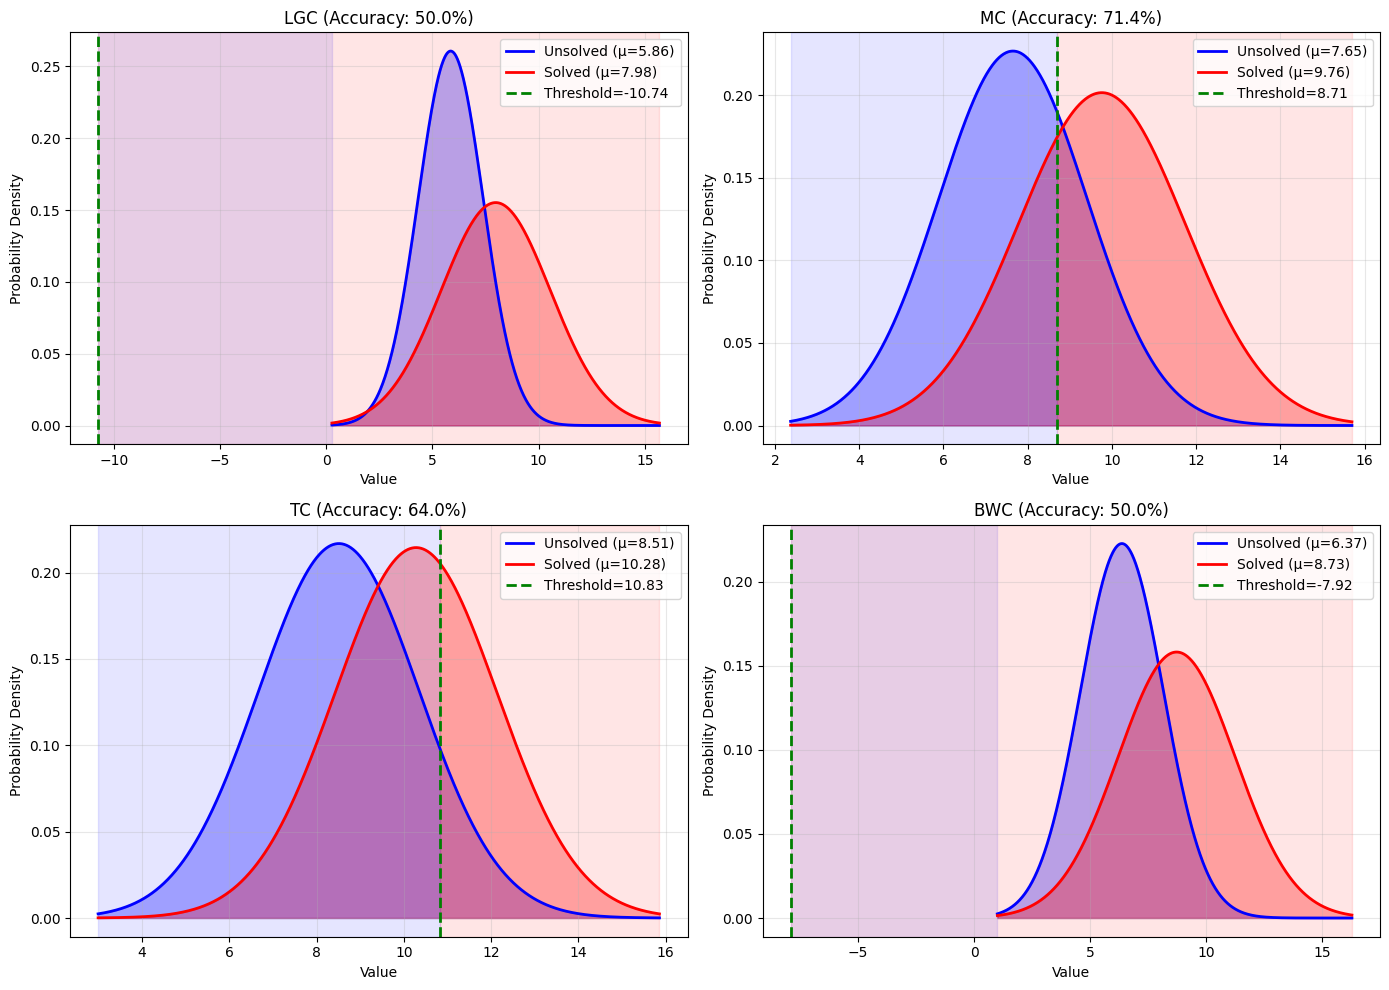

In [27]:
# Visualize all metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (metric_name, data) in enumerate(metrics_data.items()):
    ax = axes[idx]
    
    mean0, std0 = data['unsolved']
    mean1, std1 = data['solved']
    threshold = results[metric_name]['threshold']
    accuracy = results[metric_name]['accuracy']
    
    # Create x range
    x_min = min(mean0 - 3*std0, mean1 - 3*std1)
    x_max = max(mean0 + 3*std0, mean1 + 3*std1)
    x = np.linspace(x_min, x_max, 1000)
    
    # Plot distributions
    y0 = norm.pdf(x, mean0, std0)
    y1 = norm.pdf(x, mean1, std1)
    
    ax.plot(x, y0, 'b-', linewidth=2, label=f'Unsolved (μ={mean0:.2f})')
    ax.plot(x, y1, 'r-', linewidth=2, label=f'Solved (μ={mean1:.2f})')
    ax.fill_between(x, y0, alpha=0.3, color='blue')
    ax.fill_between(x, y1, alpha=0.3, color='red')
    
    # Plot threshold
    y_max = max(y0.max(), y1.max())
    ax.axvline(threshold, color='green', linestyle='--', linewidth=2, 
               label=f'Threshold={threshold:.2f}')
    
    # Shade classification regions
    ax.axvspan(x_min, threshold, alpha=0.1, color='blue')
    ax.axvspan(threshold, x_max, alpha=0.1, color='red')
    
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'{metric_name} (Accuracy: {accuracy*100:.1f}%)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('metric_separating_hyperplanes.png', dpi=300, bbox_inches='tight')
plt.show()


In [29]:
import numpy as np

def solve_optimal_threshold(mu1, std1, mu2, std2):
    """
    Calculates the threshold separating two Gaussian distributions.
    Returns two values:
    1. Bayes Optimal (Intersection of PDFs) - Minimizes Error
    2. Equal Z-score (Weighted Average) - Robust Linear Separation
    """
    
    # Method 1: Bayes Optimal (Intersection of PDFs)
    # Solves quadratic equation: Ax^2 + Bx + C = 0
    # Derived from equating: (1/s1)*exp(...) = (1/s2)*exp(...)
    a = 1/(2*std1**2) - 1/(2*std2**2)
    b = mu2/(std2**2) - mu1/(std1**2)
    c = mu1**2/(2*std1**2) - mu2**2/(2*std2**2) - np.log(std2/std1)
    
    # If variances are equal, it's linear (a=0)
    if np.isclose(a, 0):
        bayes_threshold = (mu1 + mu2) / 2
    else:
        roots = np.roots([a, b, c])
        # Select the root that lies between the two means
        bayes_threshold = next((r for r in roots if min(mu1, mu2) <= r <= max(mu1, mu2)), roots[0])

    # Method 2: Equal Z-score (Weighted Average)
    # x such that distance to mu1 (in std1 units) == distance to mu2 (in std2 units)
    # Formula: x = (mu1*std2 + mu2*std1) / (std1 + std2)
    z_score_threshold = (mu1 * std2 + mu2 * std1) / (std1 + std2)
    
    return bayes_threshold, z_score_threshold

# Your Data
metrics = {
    "LGC": {'u0': 5.86, 's0': 1.53, 'u1': 7.98, 's1': 2.57},
    "MC":  {'u0': 7.65, 's0': 1.76, 'u1': 9.76, 's1': 1.98},
    "TC":  {'u0': 8.51, 's0': 1.84, 'u1': 10.28, 's1': 1.86},
    "BWC": {'u0': 6.37, 's0': 1.79, 'u1': 8.73, 's1': 2.52}
}

print(f"{'Metric':<10} | {'Z-Score Threshold':<20} | {'Bayes Opt Threshold':<20}")
print("-" * 55)

for name, data in metrics.items():
    bayes, z_thresh = solve_optimal_threshold(data['u0'], data['s0'], data['u1'], data['s1'])
    print(f"{name:<10} | {z_thresh:<20.4f} | {bayes:<20.4f}")

Metric     | Z-Score Threshold    | Bayes Opt Threshold 
-------------------------------------------------------
LGC        | 6.6511               | 7.4499              
MC         | 8.6429               | 8.8354              
TC         | 9.3902               | 9.4111              
BWC        | 7.3501               | 7.9506              


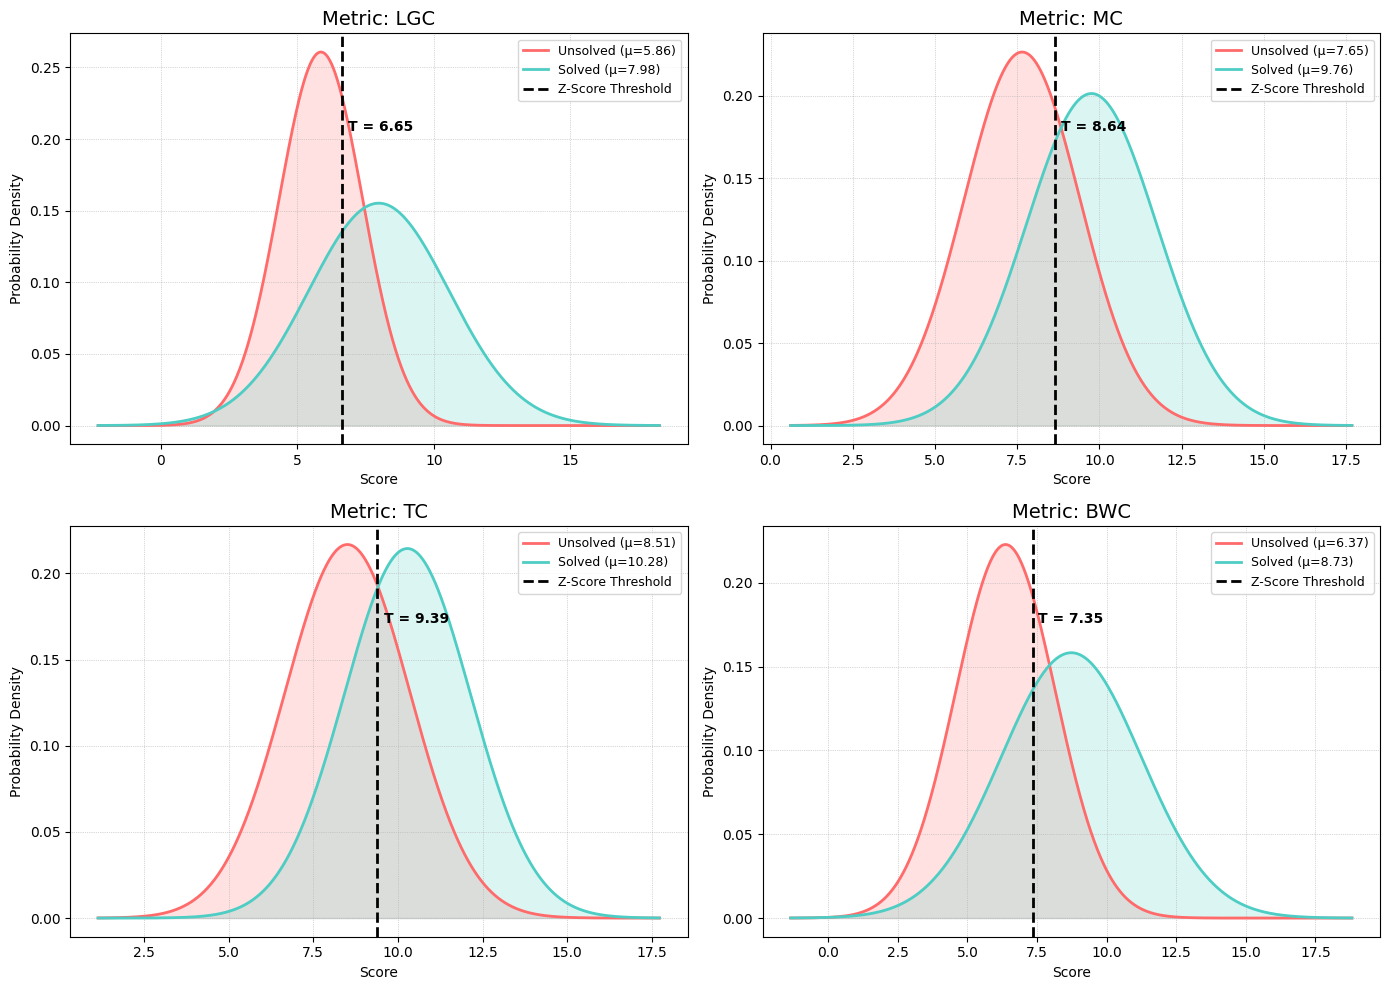

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Data Configuration
metrics = {
    "LGC": {'u0': 5.86, 's0': 1.53, 'u1': 7.98, 's1': 2.57},
    "MC":  {'u0': 7.65, 's0': 1.76, 'u1': 9.76, 's1': 1.98},
    "TC":  {'u0': 8.51, 's0': 1.84, 'u1': 10.28, 's1': 1.86},
    "BWC": {'u0': 6.37, 's0': 1.79, 'u1': 8.73, 's1': 2.52}
}

def calculate_z_threshold(u0, s0, u1, s1):
    """Calculates the Equal Z-score threshold."""
    return (u0 * s1 + u1 * s0) / (s0 + s1)

# Setup Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Flatten 2D array to 1D for easy iteration

colors = ['#FF6B6B', '#4ECDC4'] # Red-ish for Unsolved, Teal-ish for Solved

for i, (name, data) in enumerate(metrics.items()):
    ax = axes[i]
    u0, s0 = data['u0'], data['s0']
    u1, s1 = data['u1'], data['s1']
    
    # Calculate Threshold
    threshold = calculate_z_threshold(u0, s0, u1, s1)
    
    # Generate X-axis range (covering both distributions)
    x_min = min(u0 - 4*s0, u1 - 4*s1)
    x_max = max(u0 + 4*s0, u1 + 4*s1)
    x = np.linspace(x_min, x_max, 1000)
    
    # Calculate PDFs
    y0 = norm.pdf(x, u0, s0)
    y1 = norm.pdf(x, u1, s1)
    
    # Plot PDFs
    ax.plot(x, y0, color=colors[0], label=f'Unsolved (µ={u0})', linewidth=2)
    ax.fill_between(x, y0, color=colors[0], alpha=0.2)
    
    ax.plot(x, y1, color=colors[1], label=f'Solved (µ={u1})', linewidth=2)
    ax.fill_between(x, y1, color=colors[1], alpha=0.2)
    
    # Plot Threshold Line
    ax.axvline(threshold, color='black', linestyle='--', linewidth=2, label='Z-Score Threshold')
    
    # Annotate Threshold Value
    y_text_pos = max(max(y0), max(y1)) * 0.8
    ax.text(threshold + 0.2, y_text_pos, f'T = {threshold:.2f}', 
            rotation=0, verticalalignment='center', fontsize=10, fontweight='bold')

    # Styling
    ax.set_title(f"Metric: {name}", fontsize=14)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)
    ax.set_xlabel('Score')
    ax.set_ylabel('Probability Density')

plt.tight_layout()
plt.show()

### Get Params from Pickle Object

In [34]:
import pickle

# 1. Load the model from the file
with open('/app/examples/llm_selection_confidence/online_router_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# 2. Retrieve the hyperparameters
# This returns a dictionary of all parameters used to initialize the model
actual_tree_model = loaded_model['model'] 

# Now you can get the hyperparameters
# hyperparameters = actual_tree_model.get_params()
# hyperparameters = loaded_model.keys()

# 3. Print them out
import pprint
pprint.pprint(actual_tree_model)

HoeffdingTreeClassifier (
  grace_period=20
  max_depth=10
  split_criterion="info_gain"
  delta=1e-05
  tau=0.05
  leaf_prediction="nba"
  nb_threshold=0
  nominal_attributes=None
  splitter=GaussianSplitter (
    n_splits=10
  )
  binary_split=False
  min_branch_fraction=0.01
  max_share_to_split=0.99
  max_size=100.
  memory_estimate_period=1000000
  stop_mem_management=False
  remove_poor_attrs=False
  merit_preprune=True
)
